In [1]:
import json
import os
import glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [ ]:
QUESTIONS_PATH = ""  
CHAPTERS_PATH  = ""

In [3]:
def load_json_records(path: str) -> list[dict]:
    p = Path(path)
    files = sorted(p.glob("**/*.json")) if p.is_dir() else [p]

    if not files:
        raise FileNotFoundError(f"No .json files found at: {path}")

    records = []
    for fp in files:
        raw = fp.read_text(encoding="utf-8").strip()
        try:
            data = json.loads(raw)
            if isinstance(data, list): records.extend(data)
            elif isinstance(data, dict): records.append(data)
        except json.JSONDecodeError:
            for line in raw.splitlines():
                line = line.strip().rstrip(",")
                if line:
                    try:
                        records.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass
    return records


def extract_oid(value) -> str:
    if isinstance(value, dict) and "$oid" in value:
        return value["$oid"]
    return str(value) if value is not None else ""

def freq_table(series: pd.Series, label: str) -> pd.DataFrame:
    counts = series.value_counts().reset_index()
    counts.columns = [label, "count"]
    counts["pct"] = (counts["count"] / counts["count"].sum() * 100).round(1)
    return counts


In [4]:
print("Loading chapters …")
raw_chapters = load_json_records(CHAPTERS_PATH)

print("Loading questions …")
raw_questions = load_json_records(QUESTIONS_PATH)

Loading chapters …
Loading questions …


In [5]:
chapter_standard_map: dict[str, str] = {
    extract_oid(ch.get("_id")): str(ch.get("standard", "Unknown")) for ch in raw_chapters
}

In [6]:
rows = []
for doc in raw_questions:
    chapter_id = extract_oid(doc.get("chapterId"))
    rows.append({
        "medium":         doc.get("medium",  "Unknown"),
        "subject":        doc.get("subject", "Unknown"),
        "chapter_title":  (doc.get("chapter") or {}).get("title",         "Unknown"),
        "chapter_number": (doc.get("chapter") or {}).get("chapterNumber"),
        "chapterId":      chapter_id,
        "class":          doc.get("class",   "Unknown"),
        "difficulty":     doc.get("difficulty", "Unknown"),
        "answer_type":    doc.get("answerType",  "Unknown"),
        "standard":       chapter_standard_map.get(chapter_id, "Unknown"),
    })

df = pd.DataFrame(rows)
cols = df.select_dtypes(include=['object']).columns
df[cols] = df[cols].apply(lambda x: x.str.lower())
print(f"Total questions loaded into DataFrame: {len(df):,}\n")

Total questions loaded into DataFrame: 7,494



C:\Users\adity\AppData\Local\Temp\ipykernel_3580\1706941897.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = df.select_dtypes(include=['object']).columns


In [7]:
grade_dist = freq_table(df["standard"], "standard")

chapter_by_medium = (
    df.groupby(["medium", "chapter_title"])
      .size()
      .reset_index(name="count")
)

subject_by_medium = (
    df.groupby(["medium", "subject"])
      .size()
      .reset_index(name="count")
)

C:\Users\adity\AppData\Local\Temp\ipykernel_3580\2917357967.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=grade_plot, x="standard", y="count", ax=ax1, palette="Blues_d")


Text(0.5, 1.0, 'Overall Medium Split')

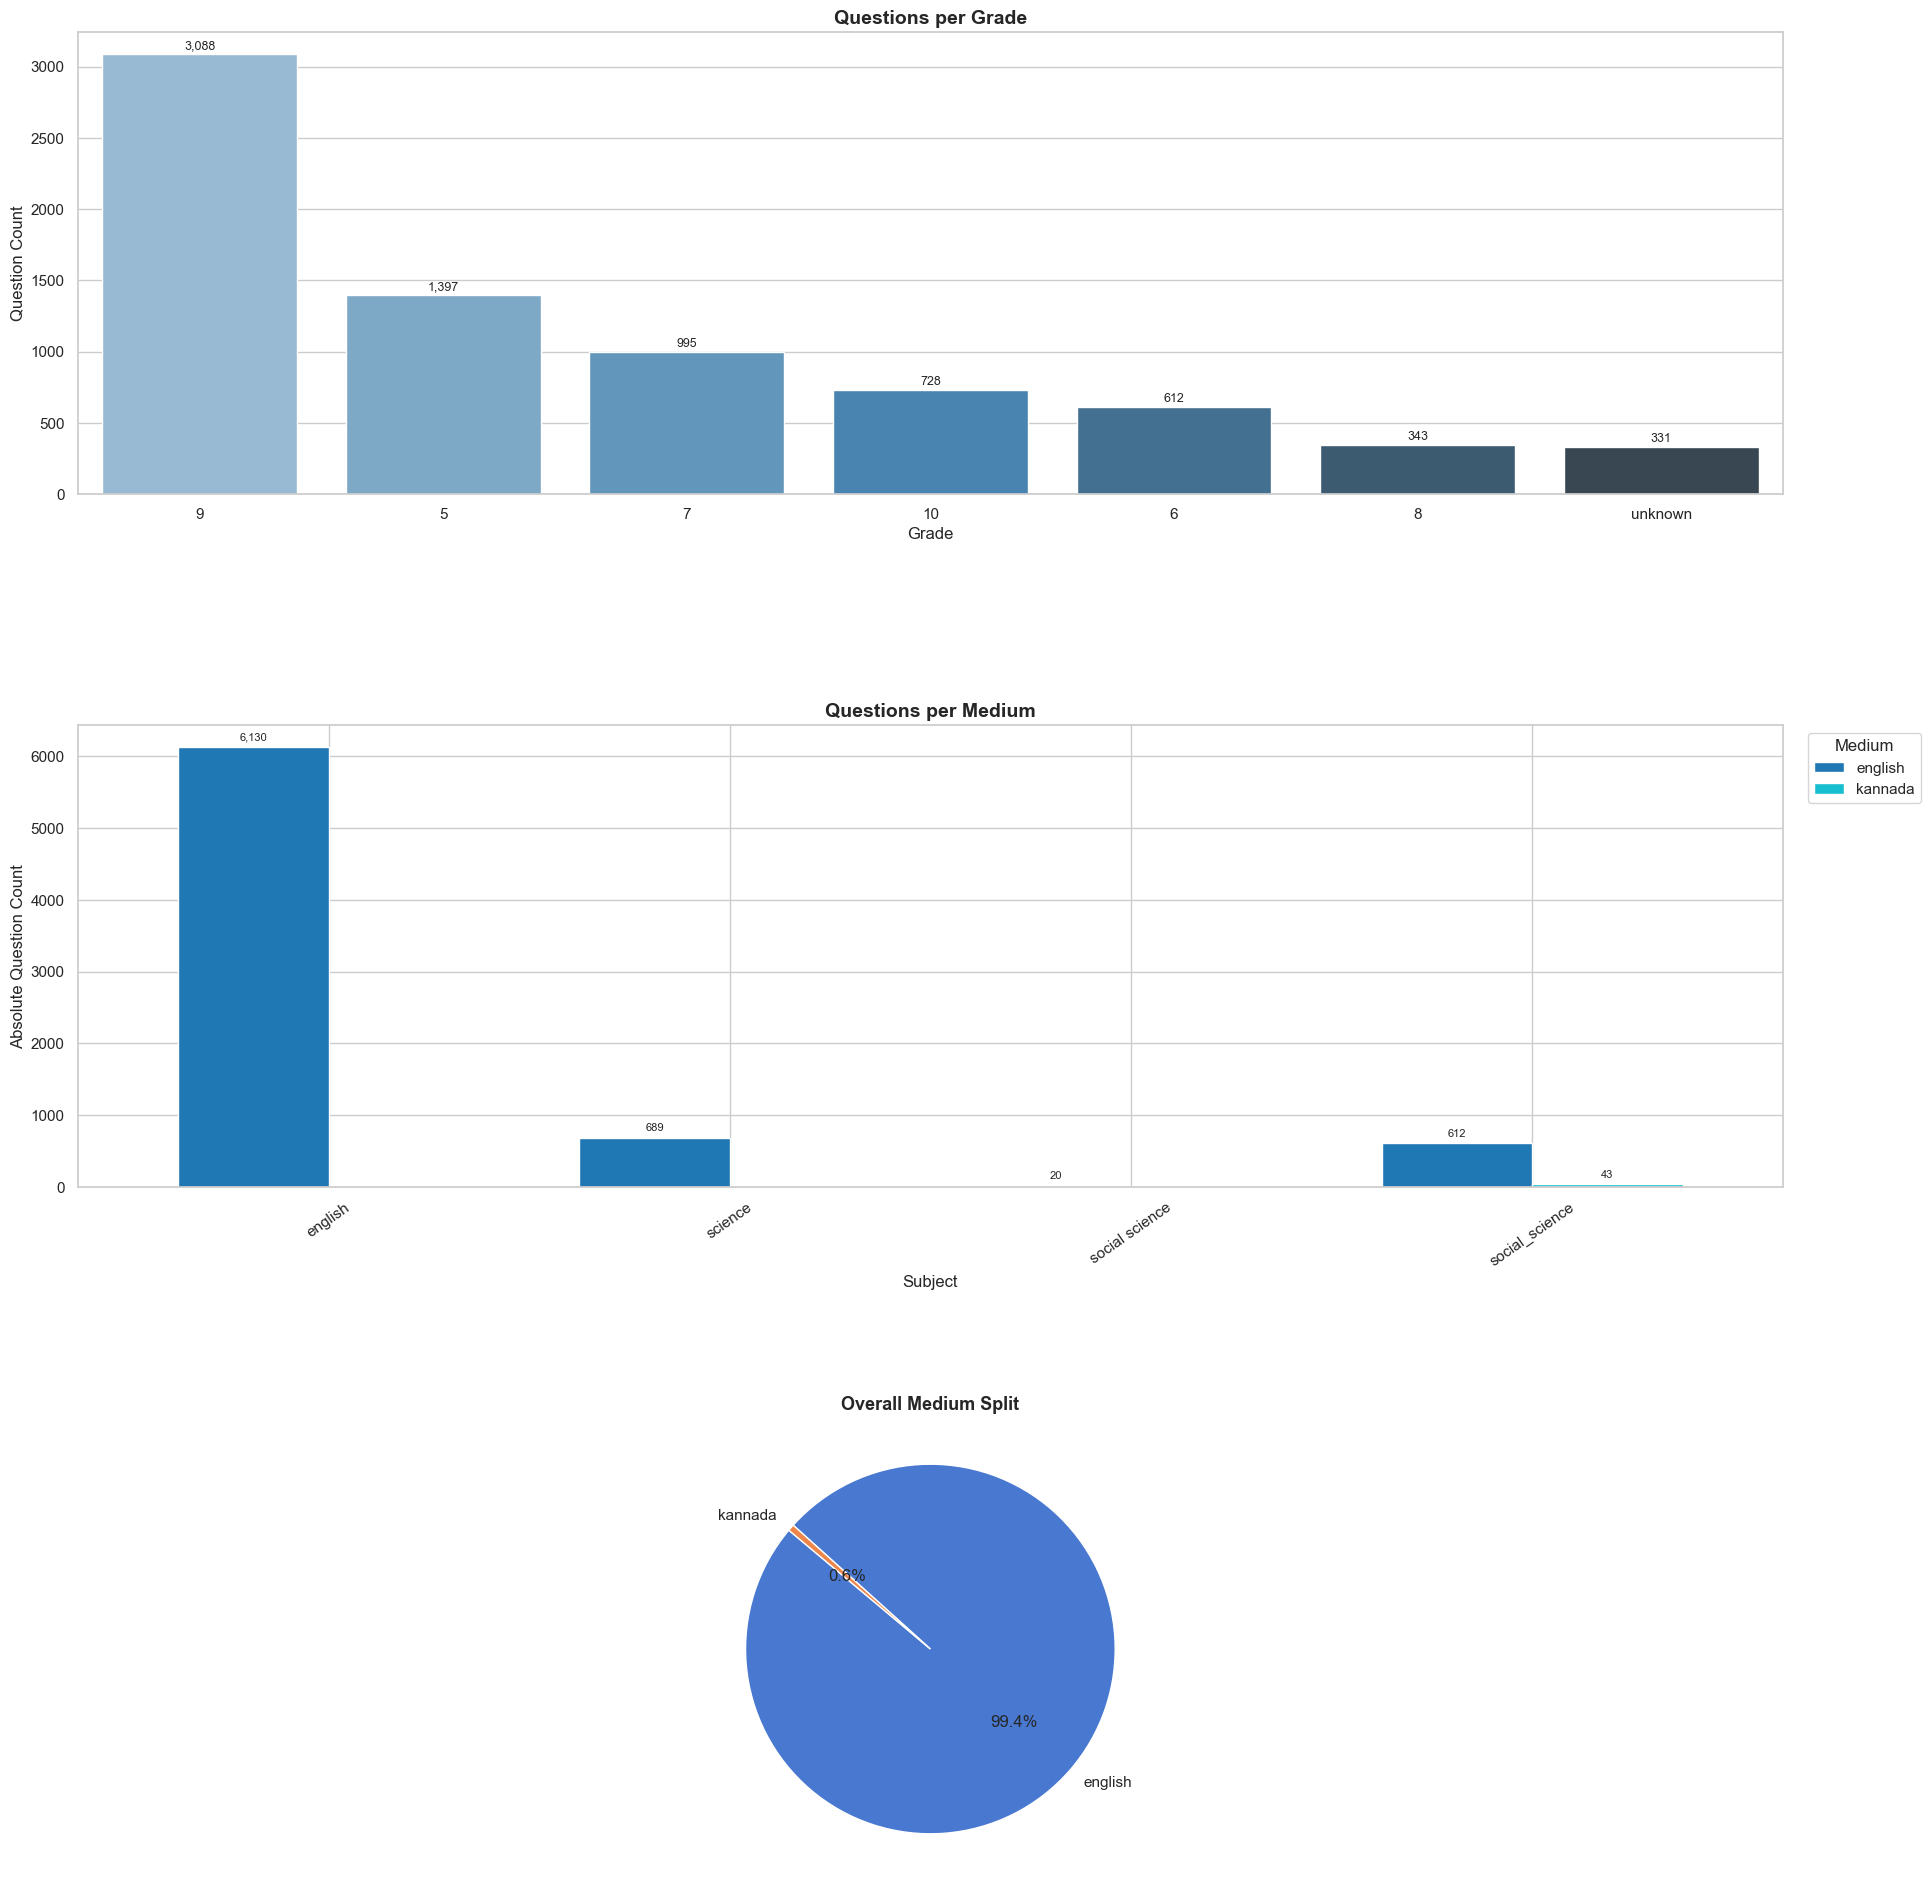

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")
fig = plt.figure(figsize=(22, 24))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.38)

#LBA Questions per Grade
ax1 = fig.add_subplot(gs[0, :])
grade_plot = (grade_dist[grade_dist["standard"] != "Unknown"]
              .sort_values("count", ascending=False))
sns.barplot(data=grade_plot, x="standard", y="count", ax=ax1, palette="Blues_d")
ax1.set_title("Questions per Grade",
              fontsize=14, fontweight="bold")
ax1.set_xlabel("Grade")
ax1.set_ylabel("Question Count")
for bar in ax1.patches:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h + ax1.get_ylim()[1] * 0.005,
             f"{int(h):,}", ha="center", va="bottom", fontsize=9)

#LBA question usage per-medium
ax2 = fig.add_subplot(gs[1, :])
pivot_subj_counts = (subject_by_medium
              .pivot(index="subject", columns="medium", values="count")
              .fillna(0))
pivot_subj_counts.plot(kind="bar", ax=ax2, colormap="tab10", width=0.75)
ax2.set_title("Questions per Medium", 
              fontsize=14, fontweight="bold")
ax2.set_xlabel("Subject")
ax2.set_ylabel("Absolute Question Count") # Changed from %
ax2.legend(title="Medium", bbox_to_anchor=(1.01, 1), loc="upper left")
ax2.tick_params(axis="x", rotation=35)

for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f"{int(p.get_height()):,}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', 
                     xytext=(0, 7), 
                     textcoords='offset points',
                     fontsize=8)

#Medium-wise usage
ax3 = fig.add_subplot(gs[2, :])
med_counts = df["medium"].value_counts()
ax3.pie(med_counts, labels=med_counts.index, autopct="%1.1f%%", startangle=140)
ax3.set_title("Overall Medium Split", fontsize=13, fontweight="bold")
